| Columna                      | Descripción                                         |
| ---------------------------- | --------------------------------------------------- |
| **Pregnancies**              | Número de embarazos                                 |
| **Glucose**                  | Nivel de glucosa en sangre (mg/dL)                  |
| **BloodPressure**            | Presión arterial diastólica (mm Hg)                 |
| **SkinThickness**            | Grosor del pliegue cutáneo del tríceps (mm)         |
| **Insulin**                  | Nivel de insulina sérica (mu U/mL)                  |
| **BMI**                      | Índice de masa corporal (kg/m²)                     |
| **DiabetesPedigreeFunction** | Función de parentesco de diabetes (riesgo familiar) |
| **Age**                      | Edad (años)                                         |
| **Outcome**                  | 1 = diabetes, 0 = no diabetes                       |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import learning_curve

### Importación del conjunto de datos

In [ ]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Calidad de datos

In [ ]:
df[df["BMI"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.0,0.232,54,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
684,5,136,82,0,0,0.0,0.640,69,0


In [ ]:
df[df["Insulin"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df[df["Glucose"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [ ]:
df[df["SkinThickness"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
762,9,89,62,0,0,22.5,0.142,33,0


In [ ]:
df["BMI"].replace(0, np.nan, inplace=True)
df["Insulin"].replace(0, np.nan, inplace=True)
df["Glucose"].replace(0, np.nan, inplace=True)
df["SkinThickness"].replace(0, np.nan, inplace=True)

/tmp/ipython-input-646010520.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["BMI"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-646010520.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
df.isnull().sum()/len(df)*100

,0
Pregnancies,0.000000
Glucose,0.651042
BloodPressure,0.000000
SkinThickness,29.557292
Insulin,48.697917
BMI,1.432292
DiabetesPedigreeFunction,0.000000
Age,0.000000
Outcome,0.000000


<Axes: >

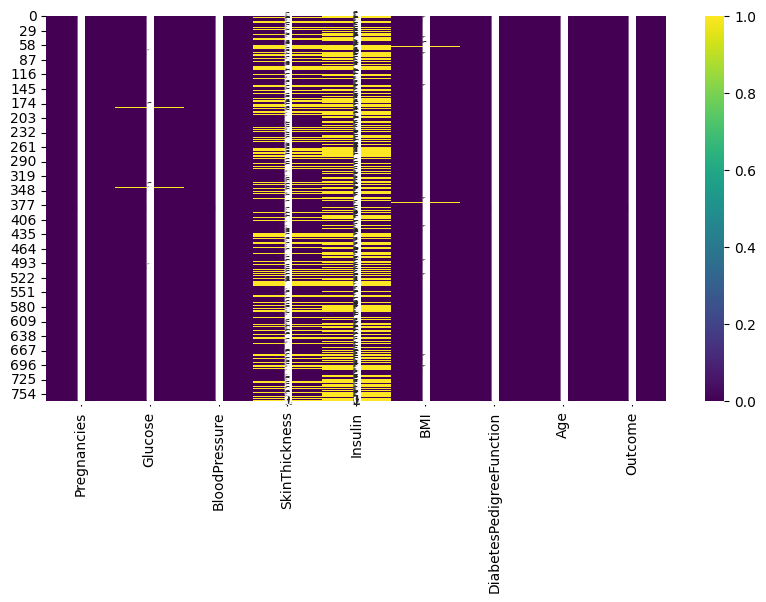

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), annot=True, cmap="viridis")

In [ ]:
df['Outcome'] = pd.Categorical(df['Outcome'])

In [ ]:
eliminar = ['SkinThickness', 'Insulin']
df.drop(eliminar, axis=1, inplace=True)

<Axes: ylabel='BMI'>

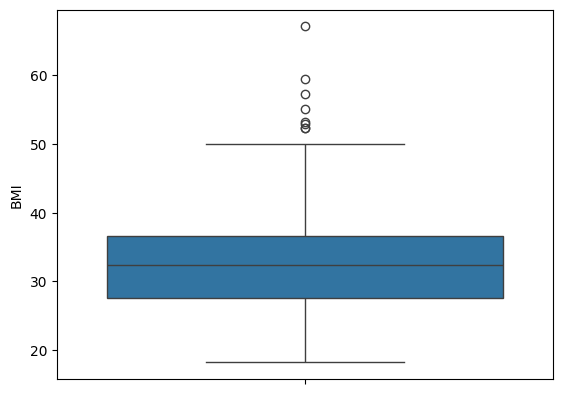

In [ ]:
sns.boxplot(df["BMI"])

In [ ]:
mediana_BMI = df["BMI"].median()
df["BMI"].fillna(mediana_BMI, inplace=True)

/tmp/ipython-input-2135254491.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["BMI"].fillna(mediana_BMI, inplace=True)


<Axes: ylabel='Glucose'>

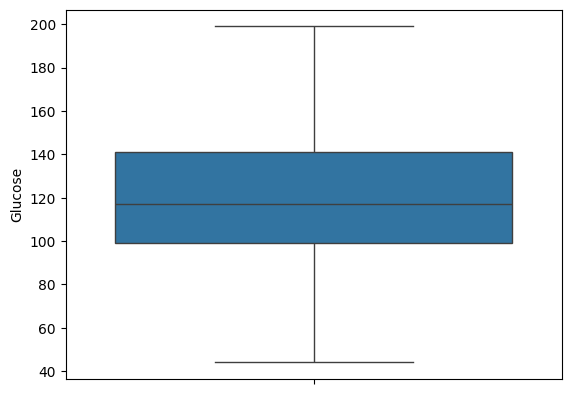

In [ ]:
sns.boxplot(df["Glucose"])

In [ ]:
media_glucose = df["Glucose"].mean()
df["Glucose"].fillna(media_glucose, inplace=True)

/tmp/ipython-input-644358380.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Glucose"].fillna(media_glucose, inplace=True)


In [ ]:
df.isnull().sum()/len(df)*100

,0
Pregnancies,0.0
Glucose,0.0
BloodPressure,0.0
BMI,0.0
DiabetesPedigreeFunction,0.0
Age,0.0
Outcome,0.0


## Vista global de relaciones: variables clínicas vs. Outcome

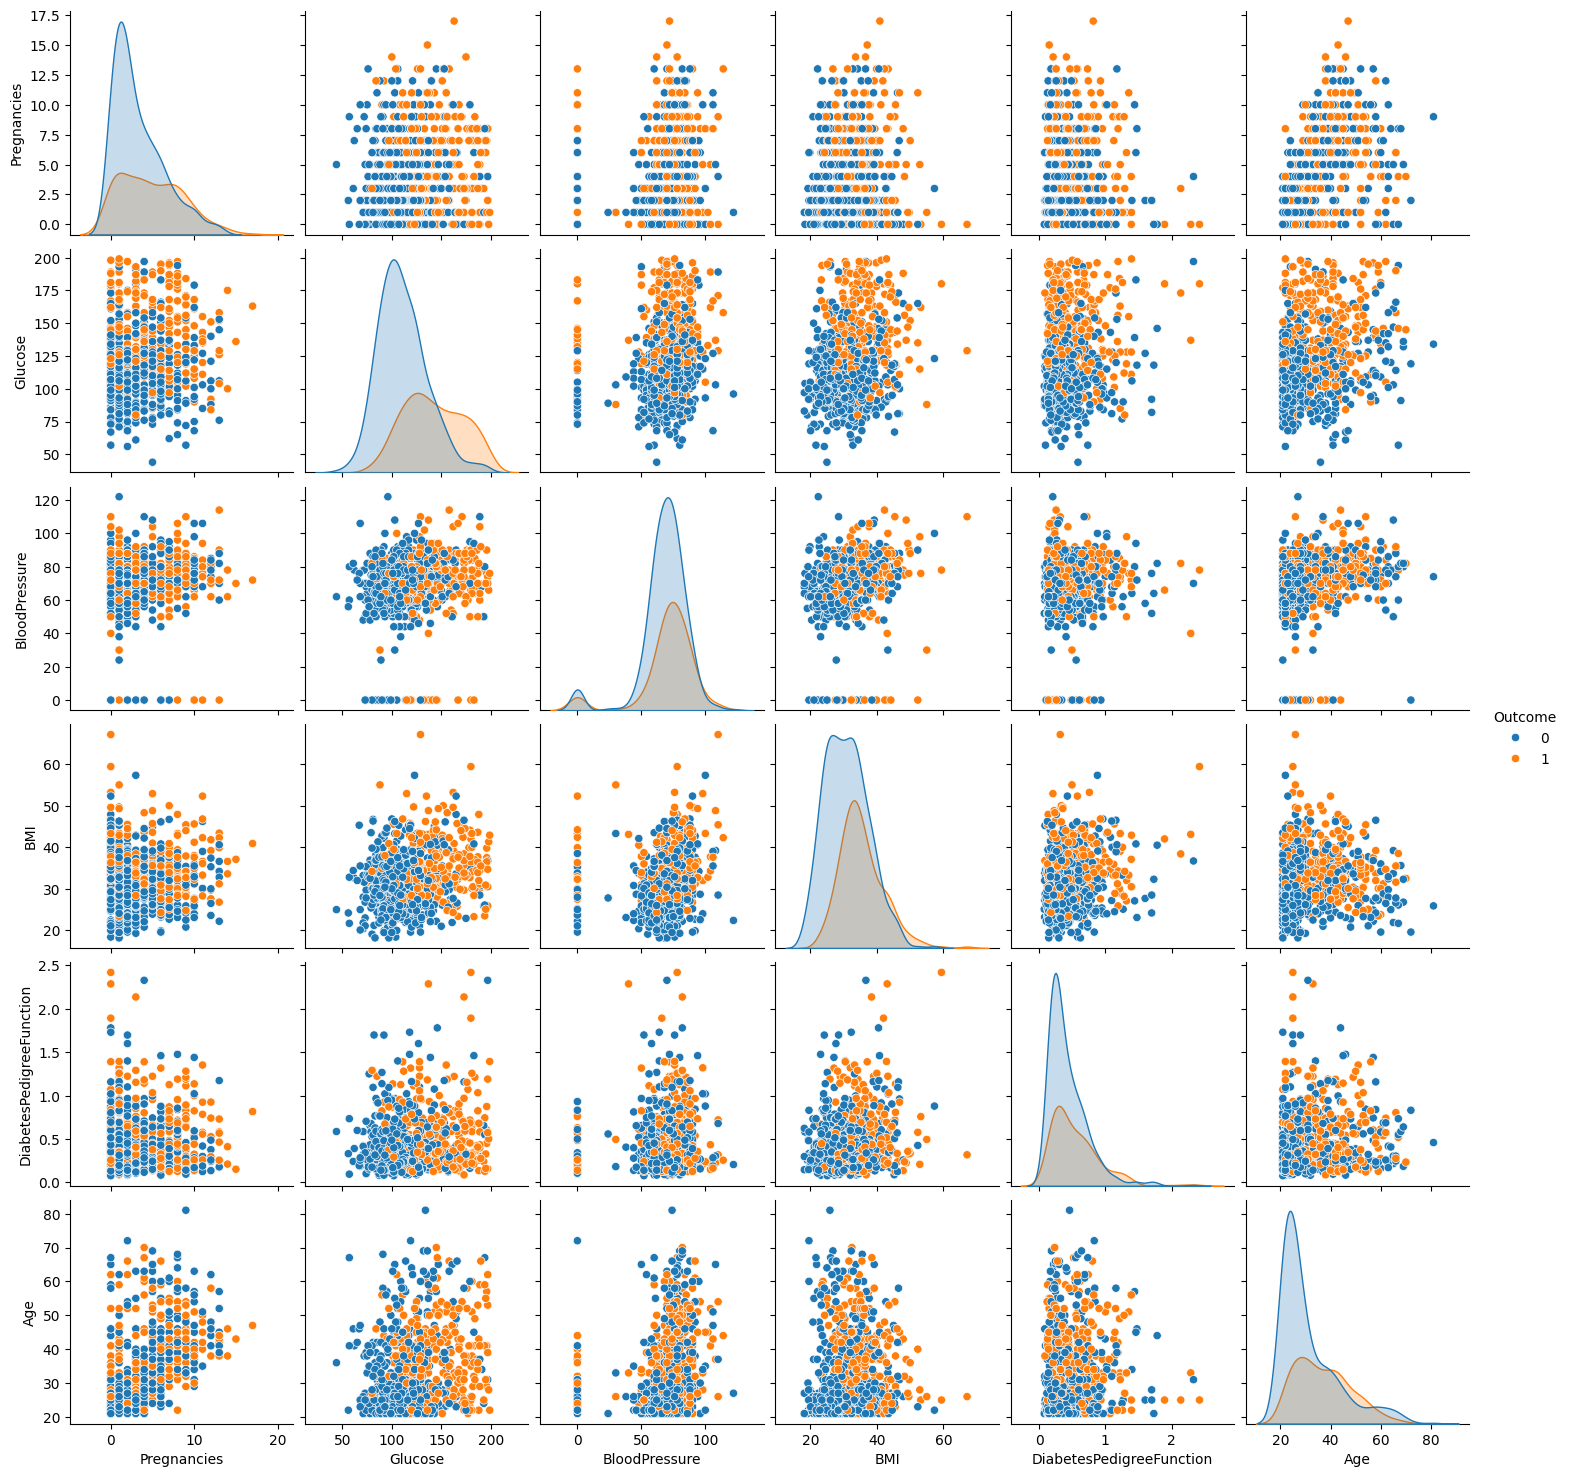

In [ ]:
sns.pairplot(data=df, hue='Outcome')

<Axes: >

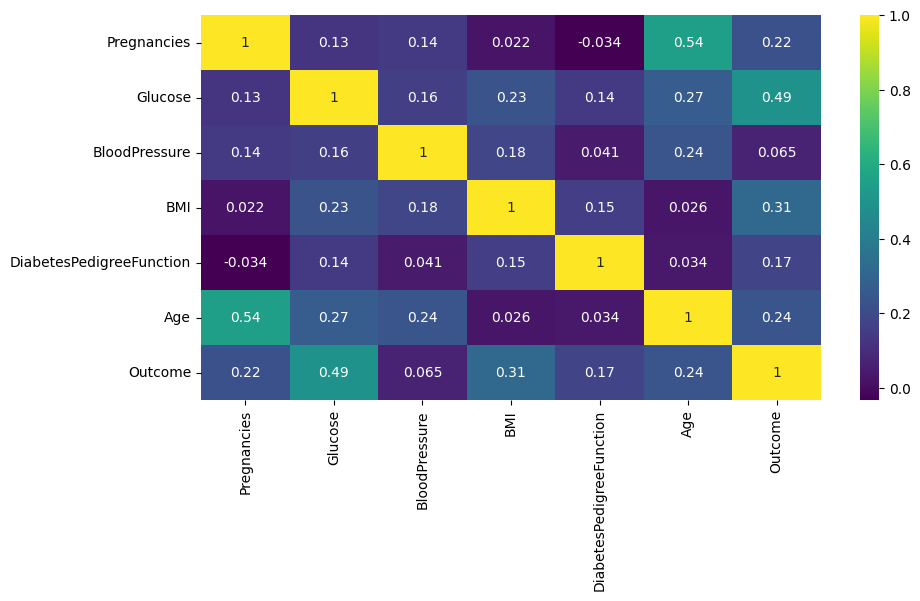

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, cmap="viridis")

In [ ]:
x=df.drop("Outcome", axis=1)
y=df["Outcome"]

<Axes: xlabel='Outcome'>

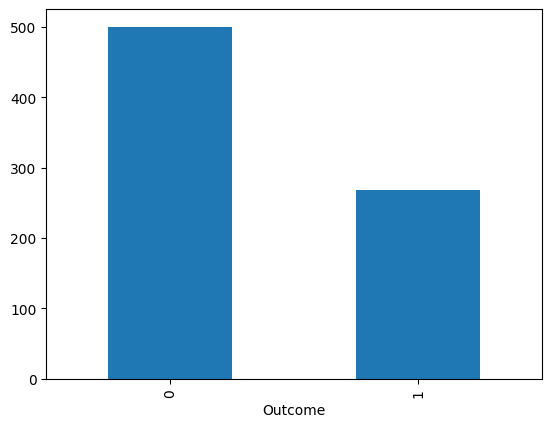

In [ ]:
df["Outcome"].value_counts().plot(kind="bar")

### Partición del conjunto de datos: entrenamiento y prueba (80/20)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape

((614, 6), (154, 6))

In [ ]:
escala = StandardScaler()
x_train = escala.fit_transform(x_train)
x_test = escala.transform(x_test)

### Entrenamiento del modelo: Regresión Logística (class_weight='balanced')

In [ ]:
RGL = sklearn.linear_model.LogisticRegression(class_weight = 'balanced')
RGL.fit(x_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred = RGL.predict(x_test)

In [ ]:
matrix = confusion_matrix(y_test, y_pred)
matrix

array([[70, 29],
       [14, 41]])

Text(95.72222222222221, 0.5, 'Real')

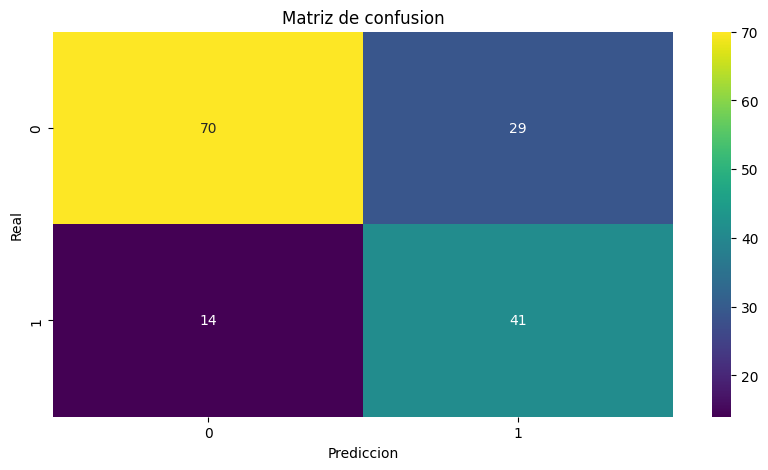

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(matrix, annot=True, cmap="viridis")
plt.title("Matriz de confusion")
plt.xlabel("Prediccion")
plt.ylabel("Real")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.71      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.74      0.72      0.73       154



Recall = 0.75 → Detectó ~41 de 55 casos de diabetes (≈ TP=41, FN=14 no detectados).

Precision = 0.59 → De todo lo que marcó como diabetes, ~59% sí lo eran. Eso implica falsos positivos relativamente altos (≈ FP=29).

F1 = 0.66 → Balance aceptable si priorizas encontrar diabéticos (recall alto) aunque con ruido (precision más baja).

## Riesgo predicho de diabetes: distribución de p(y=1) en el conjunto de prueba

In [ ]:
y_proba = RGL.predict_proba(x_test)
y_proba

array([[0.5595232 , 0.4404768 ],
       [0.76265637, 0.23734363],
       [0.84307828, 0.15692172],
       [0.75680869, 0.24319131],
       [0.39252308, 0.60747692],
       [0.36620702, 0.63379298],
       [0.97873562, 0.02126438],
       [0.23556734, 0.76443266],
       [0.30291541, 0.69708459],
       [0.13443853, 0.86556147],
       [0.66136104, 0.33863896],
       [0.06047902, 0.93952098],
       [0.4291998 , 0.5708002 ],
       [0.55952398, 0.44047602],
       [0.89055515, 0.10944485],
       [0.45524664, 0.54475336],
       [0.82205252, 0.17794748],
       [0.89080023, 0.10919977],
       [0.08128815, 0.91871185],
       [0.28958803, 0.71041197],
       [0.70725933, 0.29274067],
       [0.88792672, 0.11207328],
       [0.36431065, 0.63568935],
       [0.86215677, 0.13784323],
       [0.29672157, 0.70327843],
       [0.06939832, 0.93060168],
       [0.83801998, 0.16198002],
       [0.95810049, 0.04189951],
       [0.6354065 , 0.3645935 ],
       [0.81882125, 0.18117875],
       [0.

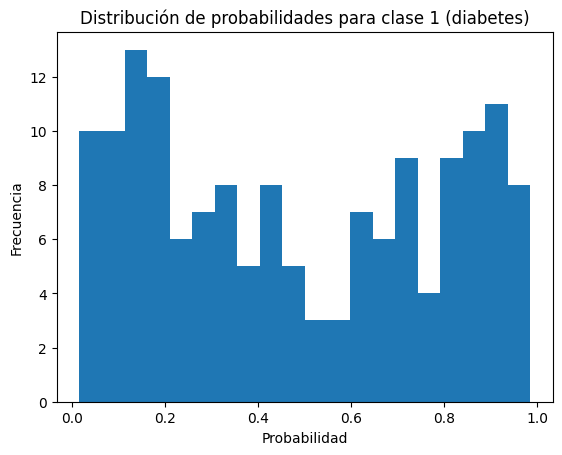

In [ ]:
plt.hist(y_proba[:,1], bins=20)
plt.title("Distribución de probabilidades para clase 1 (diabetes)")
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
calibrated_model = CalibratedClassifierCV(RGL, method='sigmoid')  # o 'isotonic'
calibrated_model.fit(x_train, y_train)


CalibratedClassifierCV(estimator=LogisticRegression(class_weight='balanced'))

In [ ]:
y_proba_calibrated = calibrated_model.predict_proba(x_test)
y_proba_calibrated

array([[0.69489879, 0.30510121],
       [0.83820834, 0.16179166],
       [0.89007766, 0.10992234],
       [0.83353616, 0.16646384],
       [0.55992978, 0.44007022],
       [0.53325871, 0.46674129],
       [0.9811493 , 0.0188507 ],
       [0.39439235, 0.60560765],
       [0.47275457, 0.52724543],
       [0.26784664, 0.73215336],
       [0.76968276, 0.23031724],
       [0.14530622, 0.85469378],
       [0.59233687, 0.40766313],
       [0.69379032, 0.30620968],
       [0.92062708, 0.07937292],
       [0.61087   , 0.38913   ],
       [0.87635776, 0.12364224],
       [0.9205738 , 0.0794262 ],
       [0.18326936, 0.81673064],
       [0.45830682, 0.54169318],
       [0.80079998, 0.19920002],
       [0.91900162, 0.08099838],
       [0.53258965, 0.46741035],
       [0.90238796, 0.09761204],
       [0.46610309, 0.53389691],
       [0.16131911, 0.83868089],
       [0.88653649, 0.11346351],
       [0.96592848, 0.03407152],
       [0.75243725, 0.24756275],
       [0.87410661, 0.12589339],
       [0.

In [ ]:
y_proba_original = RGL.predict_proba(x_test)
y_proba_original

array([[0.5595232 , 0.4404768 ],
       [0.76265637, 0.23734363],
       [0.84307828, 0.15692172],
       [0.75680869, 0.24319131],
       [0.39252308, 0.60747692],
       [0.36620702, 0.63379298],
       [0.97873562, 0.02126438],
       [0.23556734, 0.76443266],
       [0.30291541, 0.69708459],
       [0.13443853, 0.86556147],
       [0.66136104, 0.33863896],
       [0.06047902, 0.93952098],
       [0.4291998 , 0.5708002 ],
       [0.55952398, 0.44047602],
       [0.89055515, 0.10944485],
       [0.45524664, 0.54475336],
       [0.82205252, 0.17794748],
       [0.89080023, 0.10919977],
       [0.08128815, 0.91871185],
       [0.28958803, 0.71041197],
       [0.70725933, 0.29274067],
       [0.88792672, 0.11207328],
       [0.36431065, 0.63568935],
       [0.86215677, 0.13784323],
       [0.29672157, 0.70327843],
       [0.06939832, 0.93060168],
       [0.83801998, 0.16198002],
       [0.95810049, 0.04189951],
       [0.6354065 , 0.3645935 ],
       [0.81882125, 0.18117875],
       [0.

La calibración no cambia lo que el modelo “cree” que va a pasar, sino que le enseña a expresarlo con más honestidad estadística, basándose en la realidad observada.

In [ ]:
#  probabilidades de clase 1
y_proba_original = RGL.predict_proba(x_test)[:, 1]
y_proba_calibrated = calibrated_model.predict_proba(x_test)[:, 1]

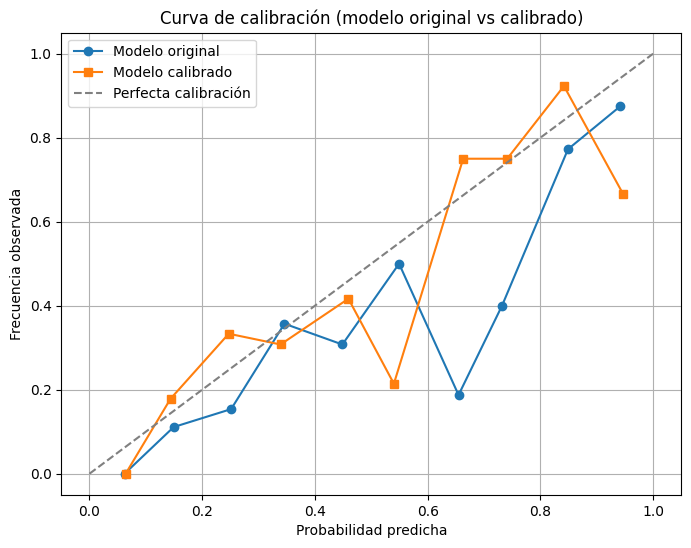

In [ ]:
# Curvas de calibración
prob_true_orig, prob_pred_orig = calibration_curve(y_test, y_proba_original, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_calibrated, n_bins=10)

# Gráfica
plt.figure(figsize=(8, 6))
plt.plot(prob_pred_orig, prob_true_orig, marker='o', label='Modelo original')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Modelo calibrado')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfecta calibración')

plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia observada')
plt.title('Curva de calibración (modelo original vs calibrado)')
plt.legend()
plt.grid()

**Modelo Azul**
En varios tramos (como entre 0.6 y 0.8), el modelo sobreestima
la probabilidad: predice alta probabilidad de diabetes pero en realidad la frecuencia real es más baja.

En la zona 0.4 a 0.6, también se ve poca estabilidad: el modelo no parece confiar con precisión en sus predicciones intermedias.

Es un modelo algo mal calibrado, aunque no catastrófico.

**Modelo naranja**
Más alineado a la diagonal en tramos clave, especialmente en el centro del rango [0.2 – 0.8].

A partir de P > 0.6, mejora la alineación con la frecuencia real.

En general, las predicciones están más cercanas a la frecuencia observada, lo que significa que el modelo calibrado tiene mejor interpretación probabilística.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Calcular las curvas
train_sizes, train_scores, val_scores = learning_curve(
    estimator=RGL,
    X=x_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10 valores de tamaño
    cv=cv,
    scoring='accuracy',  # puedes cambiar a 'f1', 'roc_auc', etc.
    n_jobs=-1
)

In [ ]:
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

In [ ]:
train_scores_mean

array([0.73877551, 0.77142857, 0.80952381, 0.79897959, 0.77959184,
       0.78231293, 0.78309038, 0.77346939, 0.77369615, 0.77026477])

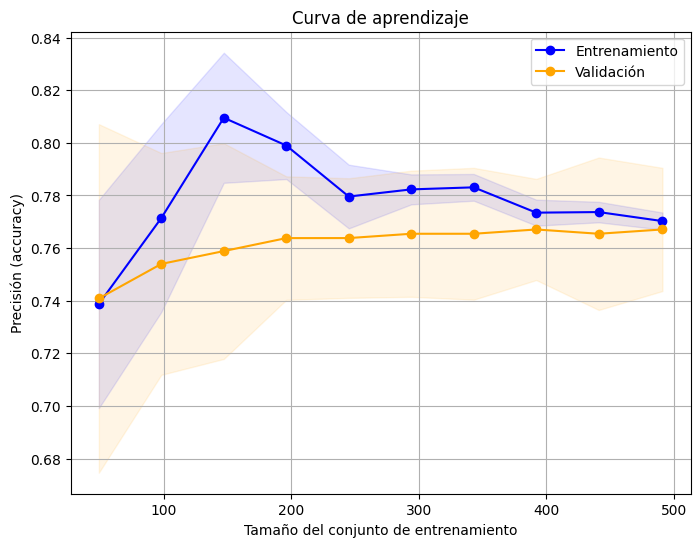

In [ ]:
# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Entrenamiento", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="blue")

plt.plot(train_sizes, val_scores_mean, 'o-', label="Validación", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color="orange")

plt.title("Curva de aprendizaje")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión (accuracy)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Precisión en entrenamiento es sistemáticamente mayor que en validación.

Indica que el modelo tiene un ligero sobreajuste: aprende bien el entrenamiento, pero pierde algo de generalización.

A medida que el tamaño del entrenamiento crece, ambas curvas tienden a estabilizarse.

Esto es bueno: indica que el modelo ya aprendió todo lo que puede con los datos actuales.

No parece haber underfitting, porque los valores se estabilizan en torno a 0.76–0.78.

In [ ]:
columnas = df.drop("Outcome", axis=1).columns  # o como corresponda

coef_df = pd.DataFrame({
    "Variable": columnas,
    "Coeficiente": RGL.coef_[0]
})
print(coef_df)

                   Variable  Coeficiente
0               Pregnancies     0.247590
1                   Glucose     1.081109
2             BloodPressure    -0.255239
3                       BMI     0.748517
4  DiabetesPedigreeFunction     0.243766
5                       Age     0.458166


In [ ]:
print("intercepto:", RGL.intercept_)

intercepto: [-0.26042957]


| Variable                 |    (\beta) | (e^{\beta}) (Odds Ratio) | ¿Qué significa ese (\beta)?                                                                        |
| ------------------------ | ---------: | -----------------------: | -------------------------------------------------------------------------------------------------- |
| Pregnancies              |  **0.248** |                 **1.28** | Por cada +1 unidad, las *odds* de diabetes aumentan ~**28%** (manteniendo lo demás constante).     |
| Glucose                  |  **1.081** |                 **2.95** | Por cada +1 unidad, las *odds* casi **se triplican** (**+195%**). Es el predictor más fuerte aquí. |
| BloodPressure            | **−0.255** |                 **0.78** | Por cada +1 unidad, las *odds* **disminuyen ~22%**.                                                |
| BMI                      |  **0.749** |                 **2.11** | Por cada +1 unidad, las *odds* se **duplican** aproximadamente (**+111%**).                        |
| DiabetesPedigreeFunction |  **0.244** |                 **1.28** | Por cada +1 unidad, las *odds* aumentan ~**28%** (mayor riesgo familiar).                          |
| Age                      |  **0.458** |                 **1.58** | Por cada +1 unidad, las *odds* aumentan ~**58%**.                                                  |
| Intercepto               | **−0.260** |                 **0.77** | *Odds* base cuando todas las X=0 (si estandarizaste, significa “en el promedio” de cada variable). |
